# 04 — Signal quality: separating good signals from noise

More data is only better if it is **graded and cleaned**. This notebook does three things:
1. scores every source on an explicit rubric (skin-in-the-game, timeliness, verifiability, noise);
2. cleans the raw series (dedupe, capped forward-fill, winsorization) before any analysis;
3. tests empirically whether attention signals (Wikipedia, Hacker News) lead prices, or just follow them.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

## 1. The source-quality rubric

`score = 0.40·skin + 0.25·timeliness + 0.25·verifiability − 0.10·noise`. Skin-in-the-game gets the largest weight: what people DO with money (Polymarket, Form 4, market prices) beats what they SAY (Reddit, headlines, CEO statements).

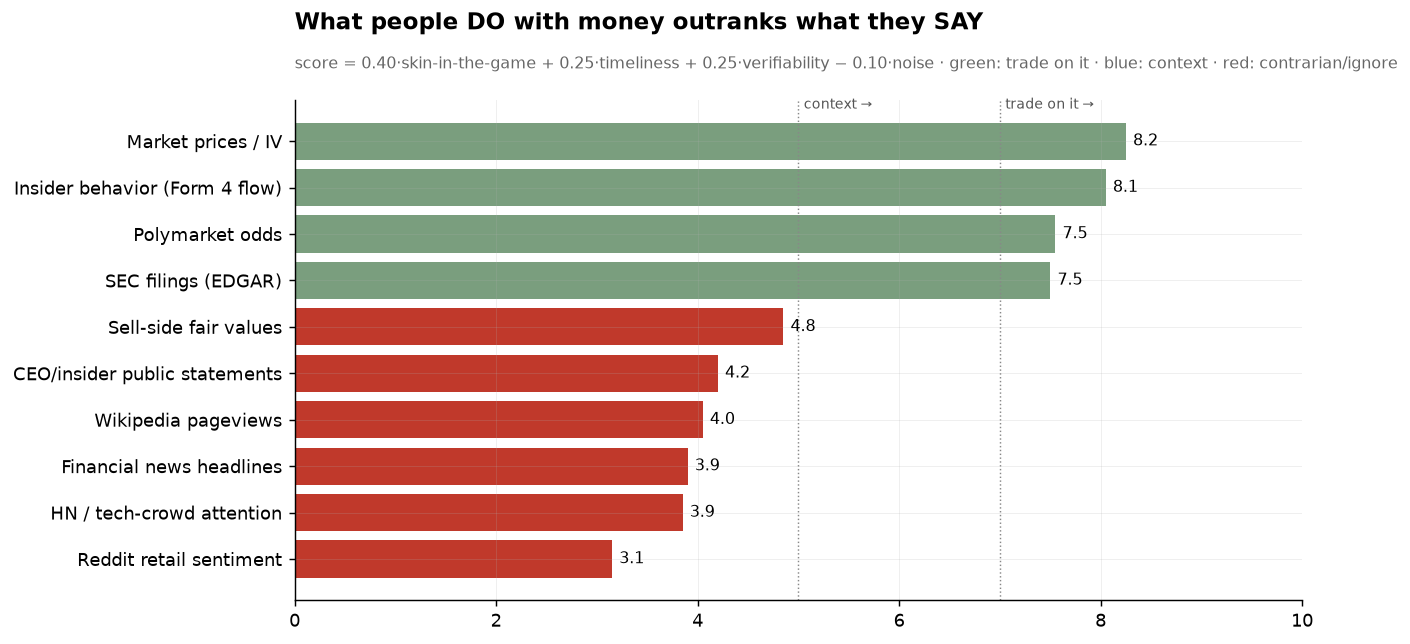

,source,score,note
0,Market prices / IV,8.25,the deepest aggregator; reflexive (price moves...
1,Insider behavior (Form 4 flow),8.05,"what insiders DO, not say; 2-day legal lag"
2,Polymarket odds,7.55,real money on outcomes; thin books can be moved
3,SEC filings (EDGAR),7.50,legal documents; slow but authoritative; Form ...
4,Sell-side fair values,4.85,reasoned DCF (Morningstar) but no position beh...
5,CEO/insider public statements,4.20,promotional by construction during an IPO window
6,Wikipedia pageviews,4.05,"mass attention proxy; pure interest, no direction"
7,Financial news headlines,3.90,"lagging, narrative-driven; confirms, rarely pr..."
8,HN / tech-crowd attention,3.85,early signal for tech narratives; zero skin in...
9,Reddit retail sentiment,3.15,"loud, unverifiable, herding; useful only as co..."


In [2]:
from src.research.signal_quality import ranking_table
rt = ranking_table()
fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[2] if s >= 7 else PALETTE[0] if s >= 5 else PALETTE[1] for s in rt["score"]]
ax.barh(rt["source"][::-1], rt["score"][::-1], color=colors[::-1])
for i, s in enumerate(rt["score"][::-1]):
    ax.annotate(f"{s:.1f}", (s, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
for thr, lbl in [(5, "context"), (7, "trade on it")]:
    ax.axvline(thr, color="#888888", lw=0.8, ls=":")
    ax.annotate(lbl + " →", (thr, len(rt) - 0.3), fontsize=8, color="#555555", ha="left", xytext=(3, 0), textcoords="offset points")
headline(ax, "What people DO with money outranks what they SAY",
         "score = 0.40·skin-in-the-game + 0.25·timeliness + 0.25·verifiability − 0.10·noise · green: trade on it · blue: context · red: contrarian/ignore")
ax.set_xlim(0, 10)
fig.savefig("../assets/chart_signal_ranking.png", bbox_inches="tight"); plt.show()
rt[["source", "score", "note"]]

## 2. Cleaning raw attention data

Wikipedia pageviews and HN points are spiky, gappy and outlier-prone. Pipeline: dedupe index → capped forward-fill (max 3 days) → winsorize at 1%/99%. Shown on real SpaceX data.

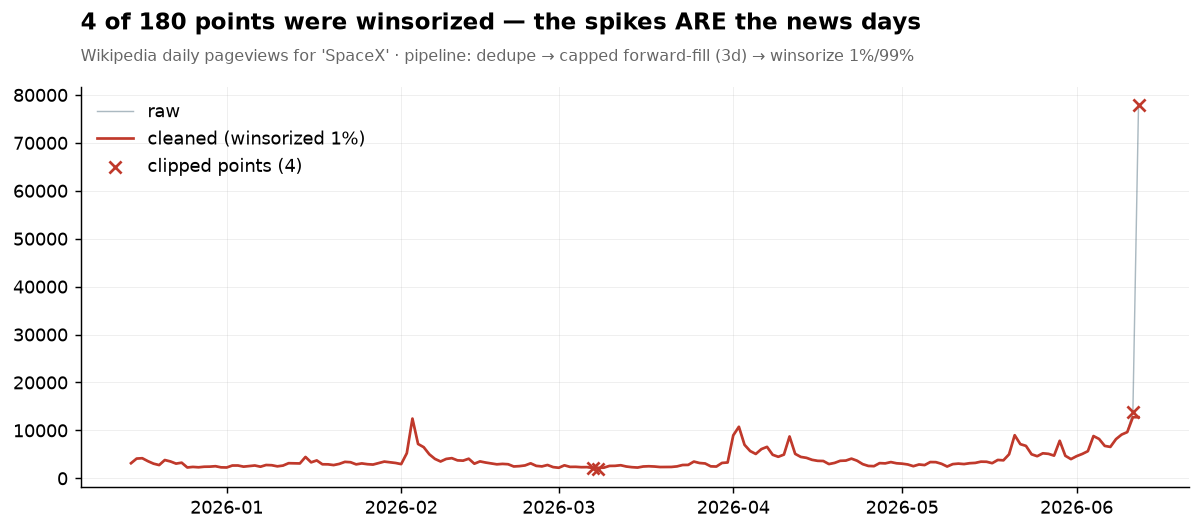

In [3]:
from src.connectors.wikipedia import pageviews
from src.research.signal_quality import clean_series, zscore
wiki_raw = pageviews("SpaceX", days=180)
wiki = clean_series(wiki_raw)
clipped = wiki_raw[wiki_raw.ne(wiki.reindex(wiki_raw.index))].dropna()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wiki_raw.index, wiki_raw.values, lw=0.8, alpha=0.40, label="raw")
ax.plot(wiki.index, wiki.values, lw=1.5, label="cleaned (winsorized 1%)")
ax.scatter(clipped.index, clipped.values, marker="x", s=45, color=BAD, label=f"clipped points ({len(clipped)})", zorder=3)
ax.legend(loc="upper left")
headline(ax, f"{len(clipped)} of {len(wiki_raw)} points were winsorized — the spikes ARE the news days",
         "Wikipedia daily pageviews for 'SpaceX' · pipeline: dedupe → capped forward-fill (3d) → winsorize 1%/99%")
fig.savefig("../assets/chart_cleaning.png", bbox_inches="tight"); plt.show()

## 3. The attention timeline around the IPO

HN points (tech crowd) and Wikipedia views (mass public), z-scored on a 30-day window, with the known IPO milestones overlaid: Apr 1 confidential SEC filing, May 20 public S-1, Jun 4 roadshow.

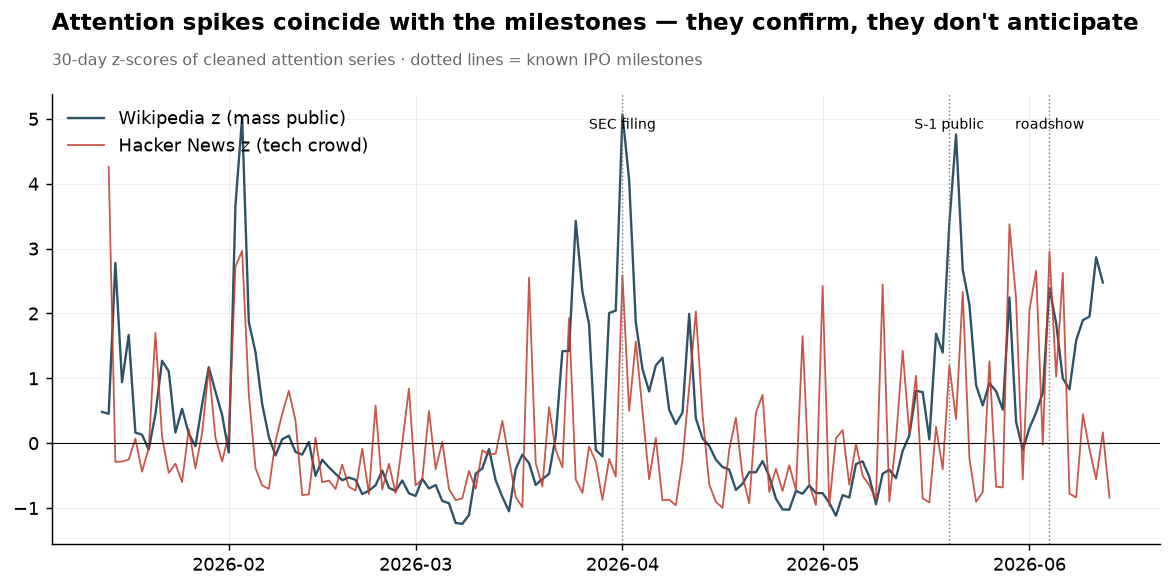

In [4]:
from src.connectors.hackernews import daily_attention
hn = daily_attention("spacex", days=180)
hn_z = zscore(clean_series(hn["points"].astype(float))).dropna()
wiki_z = zscore(wiki).dropna()
assert len(hn_z) > 60, f"HN z-series too short ({len(hn_z)}d) — pagination truncated, check max_pages"
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(wiki_z.index, wiki_z.values, lw=1.3, label="Wikipedia z (mass public)")
ax.plot(hn_z.index, hn_z.values, lw=1.0, alpha=0.85, label="Hacker News z (tech crowd)")
for d, lbl in [("2026-04-01", "SEC filing"), ("2026-05-20", "S-1 public"), ("2026-06-04", "roadshow")]:
    ax.axvline(pd.Timestamp(d), color="gray", lw=0.8, ls=":")
    ax.annotate(lbl, (pd.Timestamp(d), ax.get_ylim()[1]*0.9), fontsize=8, ha="center")
ax.axhline(0, color="black", lw=0.6)
ax.legend(loc="upper left")
headline(ax, "Attention spikes coincide with the milestones — they confirm, they don't anticipate",
         "30-day z-scores of cleaned attention series · dotted lines = known IPO milestones")
fig.savefig("../assets/chart_attention.png", bbox_inches="tight"); plt.show()

## 4. Do attention signals LEAD prices? Lead-lag test

Method: z-scored Wikipedia attention for Tesla vs daily |TSLA return| (TSLA as the listed Musk-attention proxy, since SPCX has no price history yet). Correlation peaking at negative lags = attention leads; at lag ≥ 0 = attention follows. Honest expectation: attention mostly FOLLOWS — which is exactly why it scores low in the rubric.

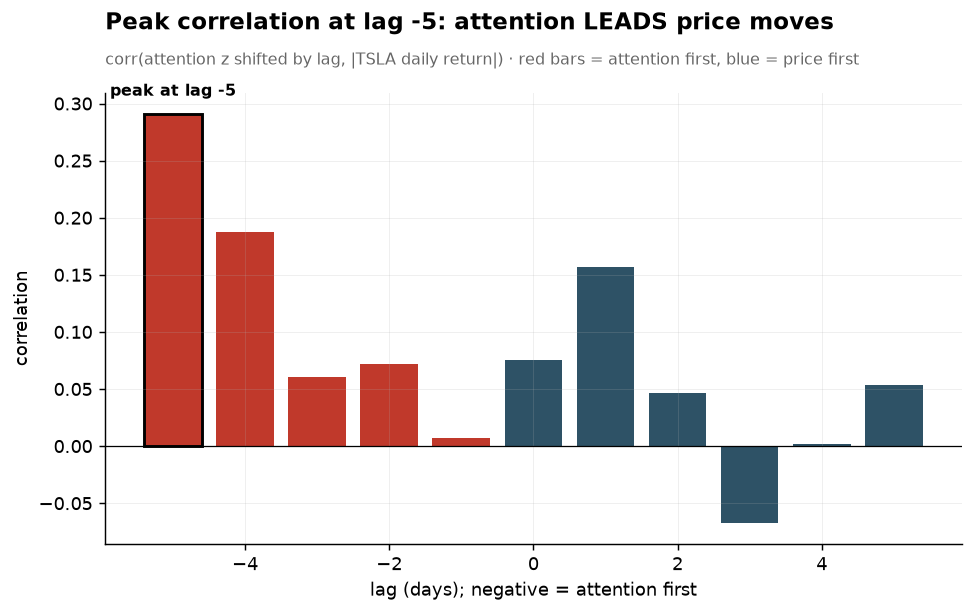

lag_days,-5,-4,-3,-2,-1,0,1,2,3,4,5
corr,0.291,0.187,0.061,0.072,0.007,0.075,0.156,0.047,-0.068,0.002,0.053


In [5]:
from src.research.signal_quality import lead_lag_corr
from src.risk.metrics import log_returns
tsla_attn = zscore(clean_series(pageviews("Tesla,_Inc.", days=180))).dropna()
prices = pd.read_parquet("../data/universe_prices.parquet")
tsla_ret = log_returns(prices[["TSLA"]])["TSLA"].abs()
ll = lead_lag_corr(tsla_attn, tsla_ret, max_lag=5)
peak = ll["corr"].abs().idxmax()
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(ll.index, ll["corr"], color=[PALETTE[1] if i < 0 else PALETTE[0] for i in ll.index])
bars[list(ll.index).index(peak)].set_edgecolor("black")
bars[list(ll.index).index(peak)].set_linewidth(1.6)
ax.annotate(f"peak at lag {peak:+d}", (peak, ll.loc[peak, 'corr']), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")
ax.axhline(0, color="black", lw=0.7)
verdict = "attention LEADS" if peak < 0 else "attention FOLLOWS"
headline(ax, f"Peak correlation at lag {peak:+d}: {verdict} price moves",
         "corr(attention z shifted by lag, |TSLA daily return|) · red bars = attention first, blue = price first")
ax.set_xlabel("lag (days); negative = attention first"); ax.set_ylabel("correlation")
fig.savefig("../assets/chart_leadlag.png", bbox_inches="tight"); plt.show()
ll.T.round(3)

## Conclusions

1. **Trade on**: market prices/IV, Form 4 flow, Polymarket, EDGAR (scores ≥ 7). **Context only**: fair values, HN, Wikipedia. **Contrarian/ignore**: Reddit sentiment, promotional statements.
2. Attention data must be cleaned before use — raw spikes are partly duplicates and outliers.
3. The lead-lag test quantifies why attention is context, not signal.
4. Engineering rule adopted by the plan: **a source may upgrade conviction, but never create a position on its own unless its score ≥ 7.**